# Case Study - API Evaluate method

##Installing package

In [ ]:
!pip install eispy2d

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 1.9 MB/s eta 0:00:00


##Importing packages

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from eispy2d.api import casestudy_api as cst
from eispy2d.core import result as rst

#Results for Born iterative Method


## Load the case study result



In [ ]:
CASE_STUDY_FILE = "api_casestudy"

study = cst.CaseStudy(import_filename=CASE_STUDY_FILE)(CASE_STUDY_FILE)

print(
    f"Loaded '{study.name}': "
    f"{len(study.test) if isinstance(study.test, list) else 1} total tests, "
    f"{study.stochastic_runs if hasattr(study, 'stochastic_runs') else getattr(study, 's_nexec', 1)} stochastic executions"
)

Loaded 'api_casestudy': 184 total tests, 30 stochastic executions


## Result extraction functions


In [ ]:
def extract_final_value(result, attribute):
    if not hasattr(result, attribute):
        return np.nan

    value = getattr(result, attribute)

    if isinstance(value, list):
        if not value:
            return np.nan
        value = value[-1]

    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)

    return np.nan


def get_substudy_indices(study, study_name):
    indices = []
    tests = study.test if isinstance(study.test, list) else [study.test]
    for idx, test_dict in enumerate(tests):
        if test_dict.get("_study") == study_name:
            indices.append(idx)
    return indices


def get_parameter_values_by_study(study, study_name, parameter):
    indices = get_substudy_indices(study, study_name)
    tests = study.test if isinstance(study.test, list) else [study.test]
    alg_params = study.algorithm_params if hasattr(study, 'algorithm_params') and study.algorithm_params else None

    values = []
    for idx in indices:
        if parameter in tests[idx]:
            values.append(tests[idx][parameter])
        elif alg_params and alg_params[idx] and parameter in alg_params[idx]:
            values.append(alg_params[idx][parameter])
        else:
            values.append(np.nan)

    return np.asarray(values)


def get_metric_mean_by_study(study, study_name, attribute):
    indices = get_substudy_indices(study, study_name)
    results = study.results

    if not isinstance(results, list):
        results = [results]

    n_executions = len(results)
    matrix = np.full((n_executions, len(indices)), np.nan)

    for exec_idx, execution in enumerate(results):
        if isinstance(execution, list):
            for sub_idx, test_idx in enumerate(indices):
                matrix[exec_idx, sub_idx] = extract_final_value(
                    execution[test_idx],
                    attribute
                )
        else:
            if 0 in indices:
                matrix[exec_idx, 0] = extract_final_value(execution, attribute)

    return np.nanmean(matrix, axis=0)


def plot_substudy(study, study_name, parameter, xlabel, title, categorical=False):
    x = get_parameter_values_by_study(study, study_name, parameter)
    epad = get_metric_mean_by_study(study, study_name, "zeta_epad")
    rn = get_metric_mean_by_study(study, study_name, "zeta_rn")

    if categorical:
        x_plot = np.arange(len(x))
        x_labels = [str(value) for value in x]
    else:
        x_plot = x
        x_labels = None

    color_epad = "tab:blue"
    color_rn = "tab:red"

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    line1 = ax1.plot(
        x_plot,
        epad,
        marker="o",
        color=color_epad,
        label="EPAD"
    )

    line2 = ax2.plot(
        x_plot,
        rn,
        marker="s",
        color=color_rn,
        label="RN"
    )

    ax1.set_xlabel(xlabel)
    ax1.set_ylabel("EPAD", color=color_epad)
    ax2.set_ylabel("RN", color=color_rn)

    ax1.tick_params(axis="y", labelcolor=color_epad)
    ax2.tick_params(axis="y", labelcolor=color_rn)

    ax1.set_title(title)

    if categorical:
        ax1.set_xticks(x_plot)
        ax1.set_xticklabels(x_labels)

    lines = line1 + line2
    labels = [line.get_label() for line in lines]
    ax1.legend(lines, labels, loc="best")

    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

## 1. Wavelength variation

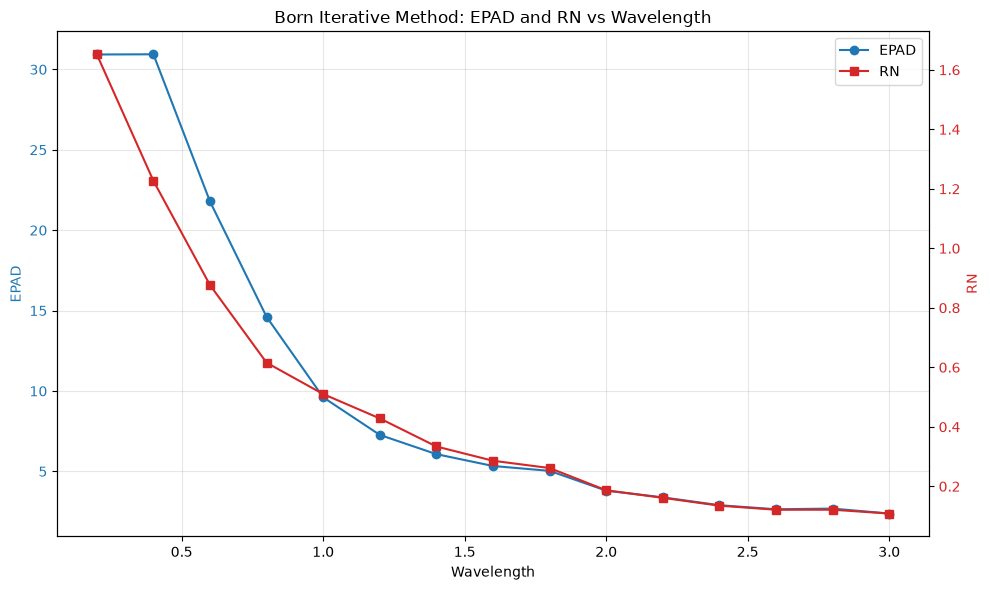

In [ ]:
plot_substudy(
    study,
    study_name="wavelength",
    parameter="wavelength",
    xlabel="Wavelength",
    title="Born Iterative Method: EPAD and RN vs Wavelength"
)

Comparing variation on PAD and RN error when increasing wavelength,
Both of them tends to decrease with grater wavelengths,

## 2. Noise variation

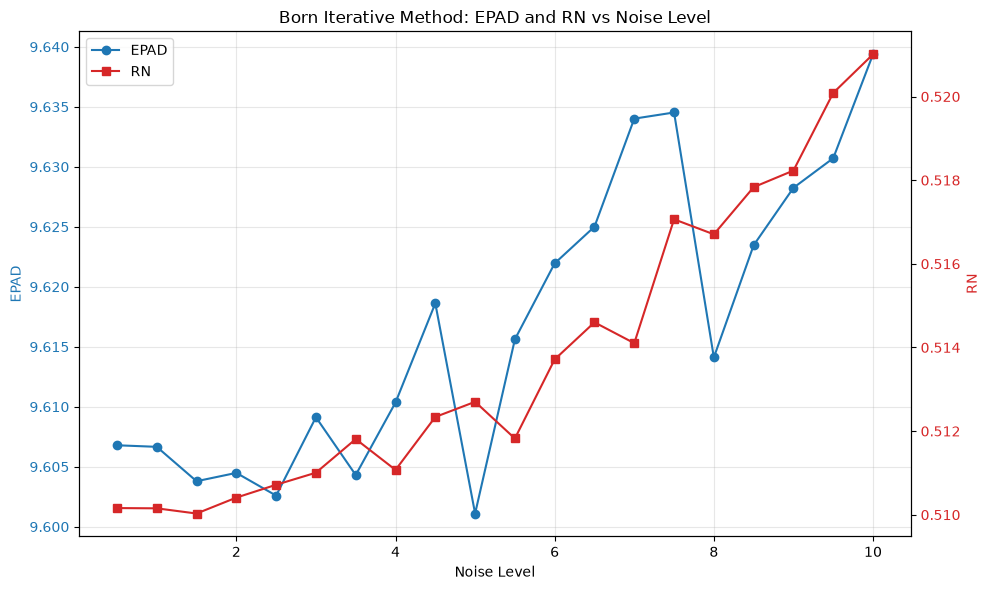

In [ ]:
plot_substudy(
    study,
    study_name="noise",
    parameter="noise_level",
    xlabel="Noise Level",
    title="Born Iterative Method: EPAD and RN vs Noise Level"
)

## 3. Number of sources (NS) variation

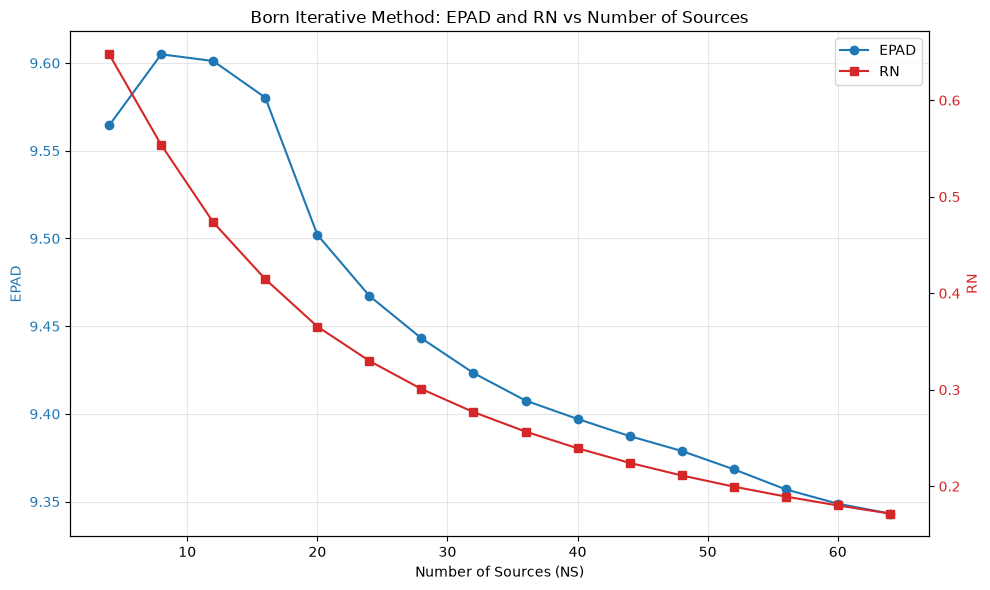

In [ ]:
plot_substudy(
    study,
    study_name="sources",
    parameter="number_sources",
    xlabel="Number of Sources (NS)",
    title="Born Iterative Method: EPAD and RN vs Number of Sources"
)

## 4. Number of measurements (NM) variation

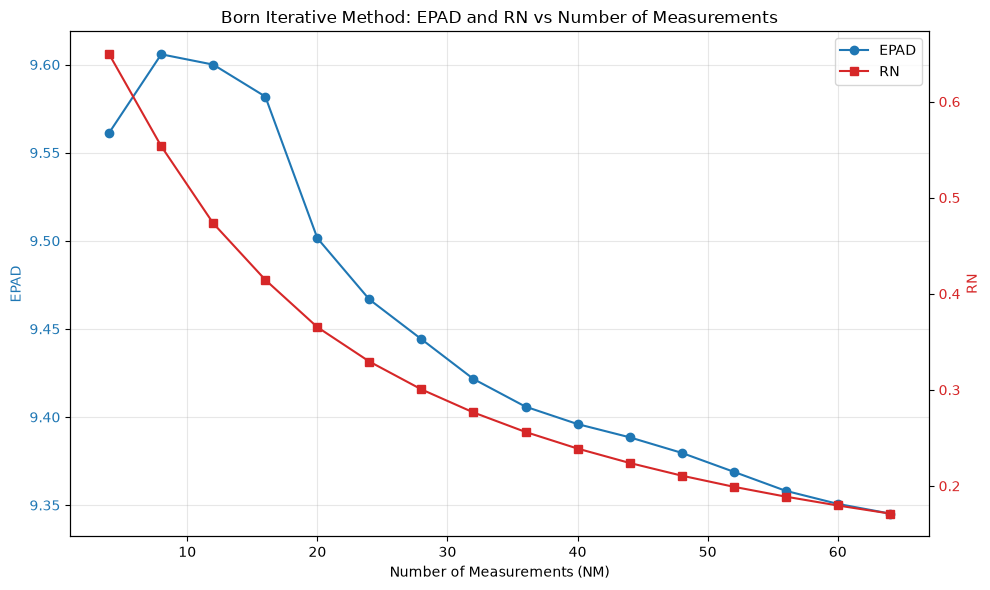

In [ ]:
plot_substudy(
    study,
    study_name="measurements",
    parameter="number_measurements",
    xlabel="Number of Measurements (NM)",
    title="Born Iterative Method: EPAD and RN vs Number of Measurements"
)

## 5. MoM Maximum iterations variation

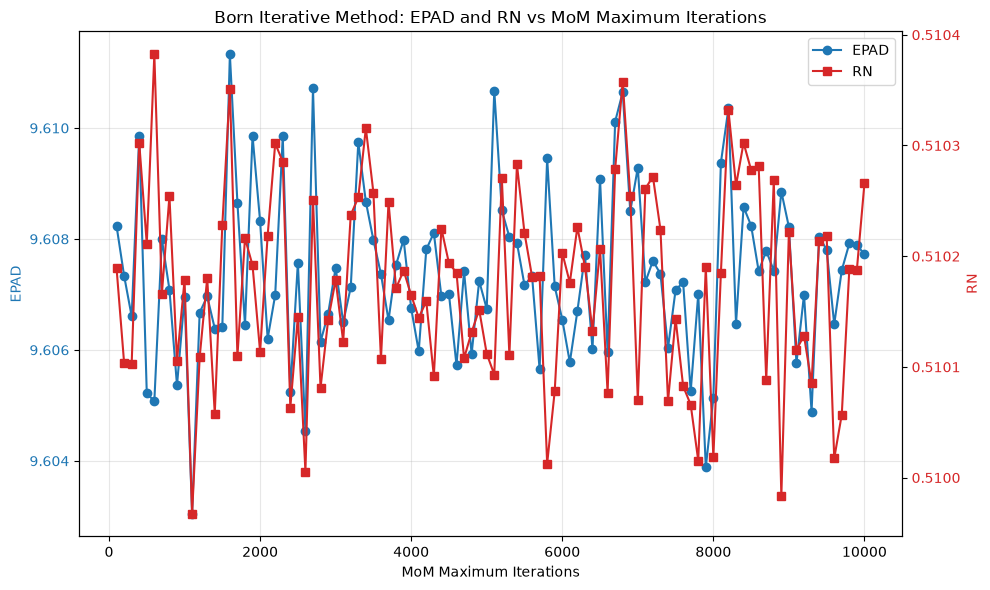

In [ ]:
plot_substudy(
    study,
    study_name="mom_max_iter",
    parameter="mom_max_iter",
    xlabel="MoM Maximum Iterations",
    title="Born Iterative Method: EPAD and RN vs MoM Maximum Iterations"
)

## 6. Stop Maximum iterations variation

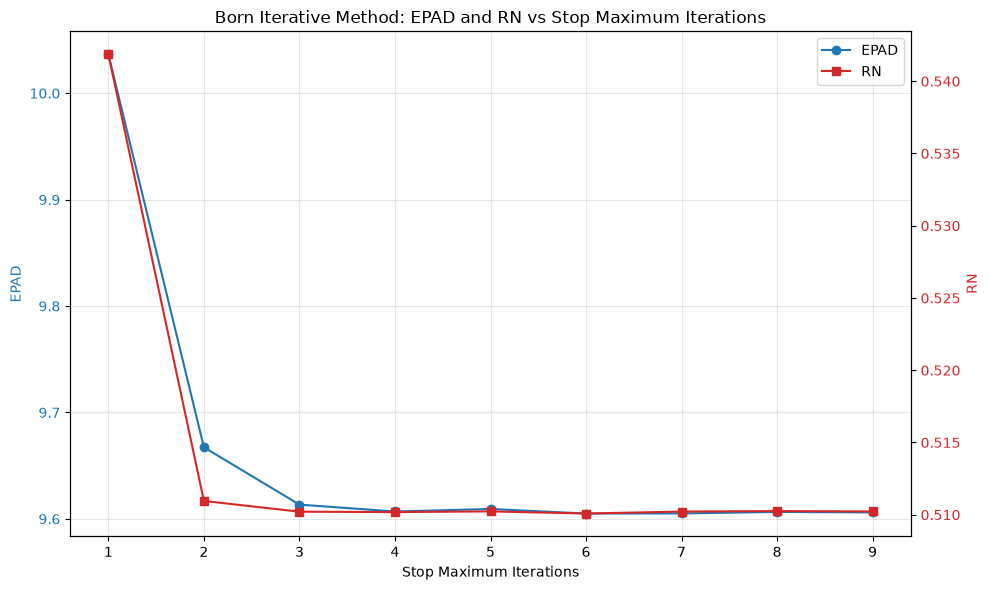

In [ ]:
plot_substudy(
    study,
    study_name="stop_max_iter",
    parameter="stop_max_iter",
    xlabel="Stop Maximum Iterations",
    title="Born Iterative Method: EPAD and RN vs Stop Maximum Iterations"
)

## 7. Tikhonov regularization variation

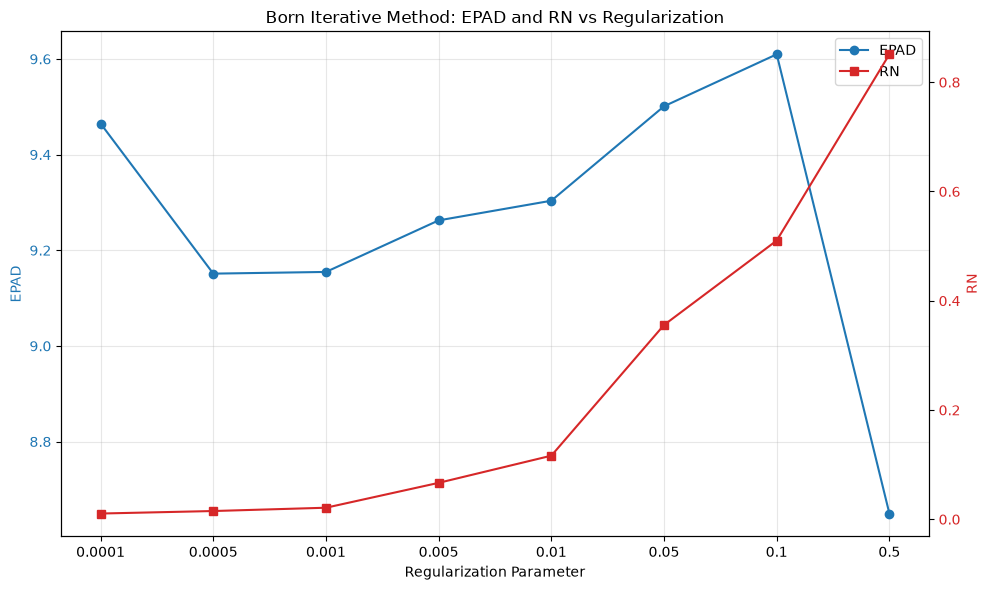

In [ ]:
plot_substudy(
    study,
    study_name="reg_tik",
    parameter="reg_tik",
    xlabel="Regularization Parameter",
    title="Born Iterative Method: EPAD and RN vs Regularization",
    categorical=True
)

## Summary of loaded parameter values

#Results for Manual Born Approximation Method


In [ ]:
CASE_STUDY_FILE = "api_casestudy_ba"

study = cst.CaseStudy(import_filename=CASE_STUDY_FILE)

print(
    f"Loaded '{study.name}': "
    f"{len(study.test) if isinstance(study.test, list) else 1} total tests, "
    f"{study.stochastic_runs if hasattr(study, 'stochastic_runs') else getattr(study, 's_nexec', 1)} stochastic executions"
)

Loaded 'api_casestudy2': 75 total tests, 30 stochastic executions


## 2.1 Wavelength variation

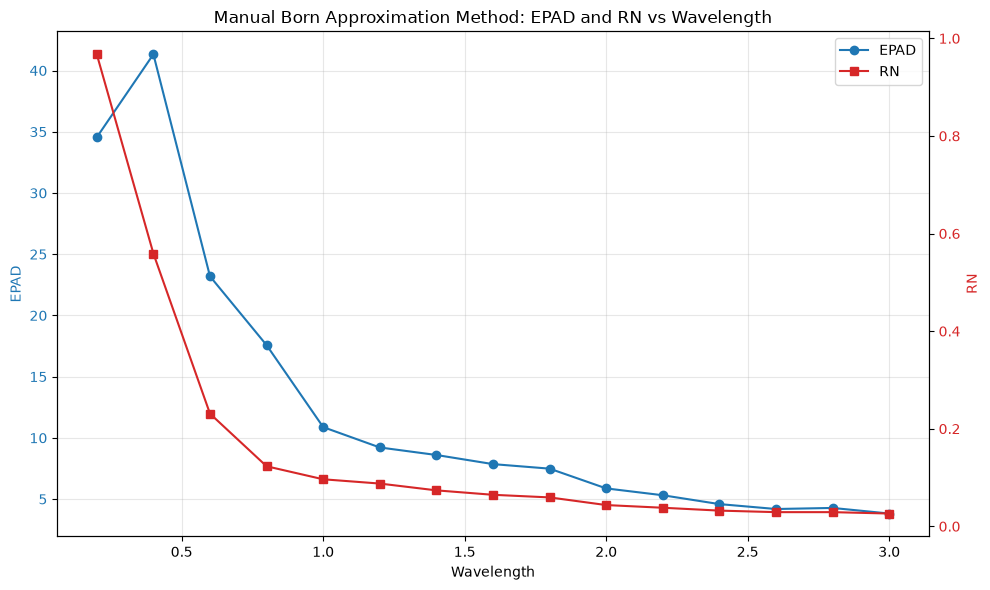

In [ ]:
plot_substudy(
    study,
    study_name="wavelength",
    parameter="wavelength",
    xlabel="Wavelength",
    title="Manual Born Approximation Method: EPAD and RN vs Wavelength"
)

## 2.2 Noise variation

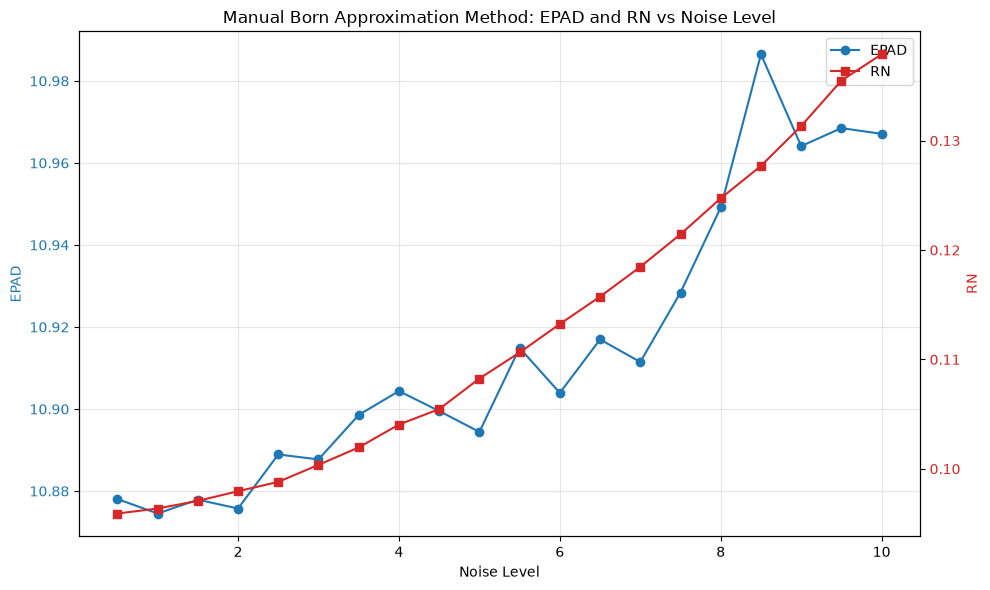

In [ ]:
plot_substudy(
    study,
    study_name="noise",
    parameter="noise_level",
    xlabel="Noise Level",
    title="Manual Born Approximation Method: EPAD and RN vs Noise Level"
)

## 2.3 Sources variation

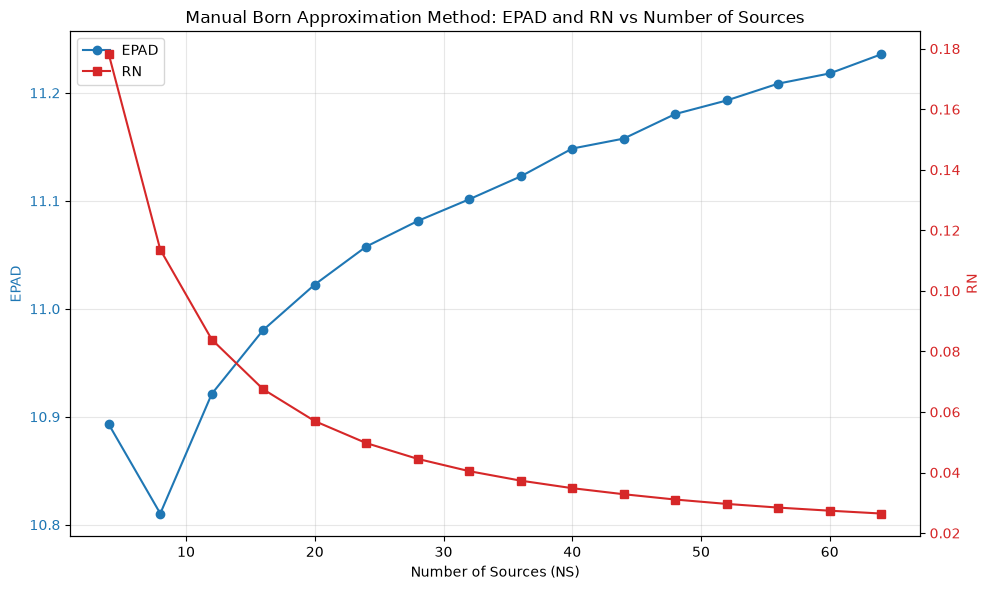

In [ ]:
plot_substudy(
    study,
    study_name="sources",
    parameter="number_sources",
    xlabel="Number of Sources (NS)",
    title="Manual Born Approximation Method: EPAD and RN vs Number of Sources"
)

## 2.4 Measurements variation

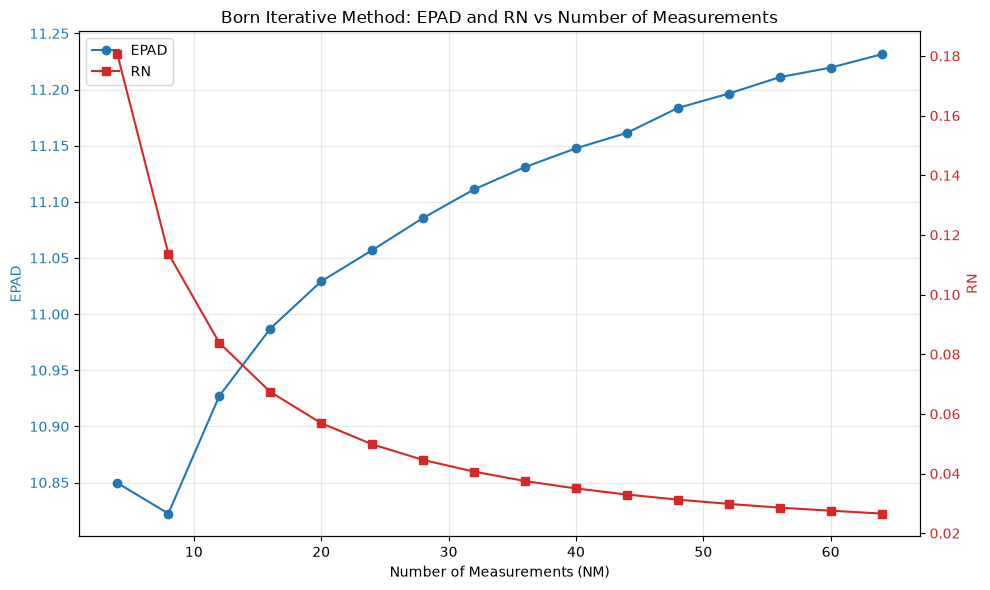

In [ ]:
plot_substudy(
    study,
    study_name="measurements",
    parameter="number_measurements",
    xlabel="Number of Measurements (NM)",
    title="Born Iterative Method: EPAD and RN vs Number of Measurements"
)

## 2.1 Tikhonov Variation variation

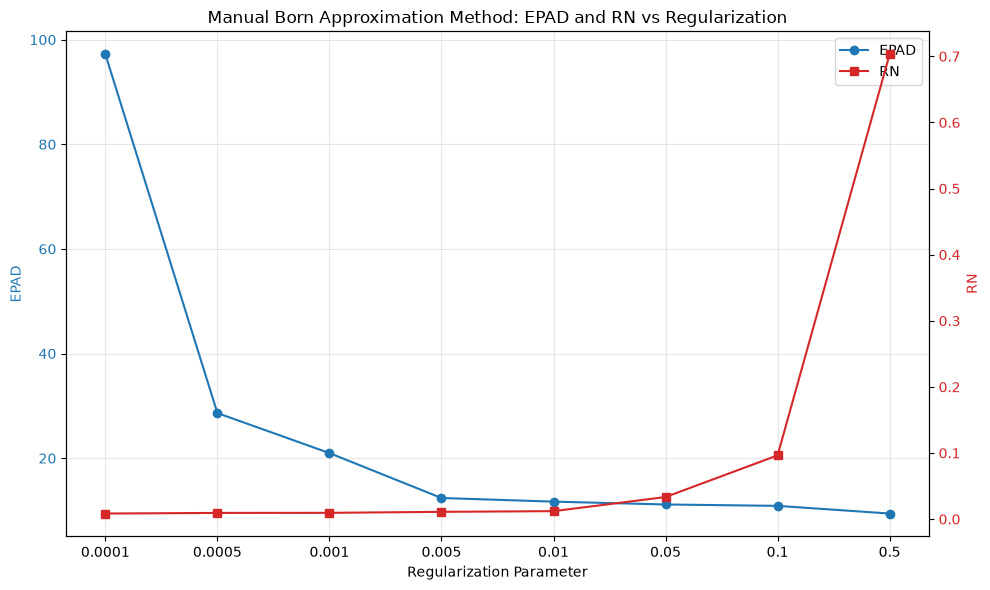

In [ ]:
plot_substudy(
    study,
    study_name="reg_tik",
    parameter="reg_tik",
    xlabel="Regularization Parameter",
    title="Manual Born Approximation Method: EPAD and RN vs Regularization",
    categorical=True
)

In [ ]:
CASE_STUDY_FILE = "api_casestudy"

study = cst.CaseStudy(import_filename=CASE_STUDY_FILE)

print(
    f"Loaded '{study.name}': "
    f"{len(study.test) if isinstance(study.test, list) else 1} total tests, "
    f"{study.stochastic_runs if hasattr(study, 'stochastic_runs') else getattr(study, 's_nexec', 1)} stochastic executions"
)

In [ ]:
print("\n--- Varying parameters for 'best_error_method' ---")

# Wavelength variation
plot_substudy(
    study_best_error,
    study_name="wavelength",
    parameter="wavelength",
    xlabel="Wavelength",
    title="Best Error Method: EPAD and RN vs Wavelength"
)

# Noise variation
plot_substudy(
    study_best_error,
    study_name="noise",
    parameter="noise_level",
    xlabel="Noise Level",
    title="Best Error Method: EPAD and RN vs Noise Level"
)

# Number of sources (NS) variation
plot_substudy(
    study_best_error,
    study_name="sources",
    parameter="number_sources",
    xlabel="Number of Sources (NS)",
    title="Best Error Method: EPAD and RN vs Number of Sources"
)

# Number of measurements (NM) variation
plot_substudy(
    study_best_error,
    study_name="measurements",
    parameter="number_measurements",
    xlabel="Number of Measurements (NM)",
    title="Best Error Method: EPAD and RN vs Number of Measurements"
)

In [ ]:
from eispy2d.core import result as rst

def extract_algorithm_data_from_study(study):
    if not hasattr(study, 'algorithm_params') or not study.algorithm_params:
        print("WARNING: 'algorithm_params' not found in study. Cannot extract cand_n/quant_rep data.")
        return {'cand_n': {}, 'quant_rep': {}}

    tests = study.test if isinstance(study.test, list) else [study.test]
    alg_params = study.algorithm_params
    results = study.results

    if not isinstance(results, list):
        results = [results]

    data = {
        'cand_n': {},
        'quant_rep': {}
    }

    for i, test_dict in enumerate(tests):
        study_name = test_dict.get('_study')
        if study_name in data and i < len(alg_params) and alg_params[i]:
            param_name = list(alg_params[i].keys())[0]
            param_value = alg_params[i][param_name]

            epad_values = []
            rn_values = []

            for execution_results in results:
                result_obj = None
                if isinstance(execution_results, list):
                    if i < len(execution_results):
                        result_obj = execution_results[i]
                else:
                    if i == 0 and not isinstance(execution_results, list):
                        result_obj = execution_results

                if result_obj:
                    epad = result_obj.final_value(rst.REL_PERMITTIVITY_PAD_ERROR)
                    rn = result_obj.final_value(rst.RESIDUAL_NORM_ERROR)

                    if not np.isnan(epad): epad_values.append(epad)
                    if not np.isnan(rn): rn_values.append(rn)

            if param_value not in data[study_name]:
                data[study_name][param_value] = {'epad': [], 'rn': []}

            data[study_name][param_value]['epad'].extend(epad_values)
            data[study_name][param_value]['rn'].extend(rn_values)

    final_data = {'cand_n': {}, 'quant_rep': {}}
    for study_name in final_data.keys():
        if study_name in data:
            for value, metrics in data[study_name].items():
                final_data[study_name][value] = {
                    'zeta_epad': np.mean(metrics['epad']) if metrics['epad'] else np.nan,
                    'zeta_rn': np.mean(metrics['rn']) if metrics['rn'] else np.nan
                }
    return final_data

algorithm_data = extract_algorithm_data_from_study(study_best_error)

print("Data extracted for cand_n and quant_rep.")
print(f"cand_n values found: {sorted(algorithm_data['cand_n'].keys())}")
print(f"quant_rep values found: {sorted(algorithm_data['quant_rep'].keys())}")

In [ ]:
quant_rep_vals = sorted(algorithm_data['quant_rep'].keys())
if quant_rep_vals:
    epad_qr = [algorithm_data['quant_rep'][v]['zeta_epad'] for v in quant_rep_vals]
    rn_qr = [algorithm_data['quant_rep'][v]['zeta_rn'] for v in quant_rep_vals]

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    line1 = ax1.plot(quant_rep_vals, epad_qr, marker="o", color="tab:blue", label="EPAD")
    line2 = ax2.plot(quant_rep_vals, rn_qr, marker="s", color="tab:red", label="RN")

    ax1.set_xlabel("quant_rep")
    ax1.set_ylabel("EPAD", color="tab:blue")
    ax2.set_ylabel("RN", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax1.set_title("Best Error Method: EPAD and RN vs quant_rep")
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="best")
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No 'quant_rep' data to plot.")

cand_n_vals = sorted(algorithm_data['cand_n'].keys())
if cand_n_vals:
    epad_cn = [algorithm_data['cand_n'][v]['zeta_epad'] for v in cand_n_vals]
    rn_cn = [algorithm_data['cand_n'][v]['zeta_rn'] for v in cand_n_vals]

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax2 = ax1.twinx()

    line1 = ax1.plot(cand_n_vals, epad_cn, marker="o", color="tab:blue", label="EPAD")
    line2 = ax2.plot(cand_n_vals, rn_cn, marker="s", color="tab:red", label="RN")

    ax1.set_xlabel("cand_n")
    ax1.set_ylabel("EPAD", color="tab:blue")
    ax2.set_ylabel("RN", color="tab:red")
    ax1.tick_params(axis="y", labelcolor="tab:blue")
    ax2.tick_params(axis="y", labelcolor="tab:red")
    ax1.set_title("Best Error Method: EPAD and RN vs cand_n")
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="best")
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No 'cand_n' data to plot.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cand_n_vals = sorted(algorithm_data['cand_n'].keys())
quant_rep_vals = sorted(algorithm_data['quant_rep'].keys())

max_cols = max(len(cand_n_vals), len(quant_rep_vals))
epad_grid = np.full((2, max_cols), np.nan)
rn_grid = np.full((2, max_cols), np.nan)

for j, cn in enumerate(cand_n_vals):
    epad_grid[0, j] = algorithm_data['cand_n'][cn]['zeta_epad']
    rn_grid[0, j] = algorithm_data['cand_n'][cn]['zeta_rn']

for j, qr in enumerate(quant_rep_vals):
    epad_grid[1, j] = algorithm_data['quant_rep'][qr]['zeta_epad']
    rn_grid[1, j] = algorithm_data['quant_rep'][qr]['zeta_rn']

x_labels = []
for j in range(max_cols):
    cn_label = str(cand_n_vals[j]) if j < len(cand_n_vals) else ''
    qr_label = str(quant_rep_vals[j]) if j < len(quant_rep_vals) else ''
    x_labels.append(f"{cn_label}\n{qr_label}")

plt.figure(figsize=(10, 4))
im = plt.imshow(epad_grid, aspect='auto', cmap='viridis')
plt.colorbar(im, label='zeta_epad')
plt.yticks([0, 1], ['cand_n', 'quant_rep'])
plt.xticks(np.arange(max_cols), labels=x_labels)
plt.title('Map of zeta_epad (separate rows per parameter)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
im = plt.imshow(rn_grid, aspect='auto', cmap='plasma')
plt.colorbar(im, label='zeta_rn')
plt.yticks([0, 1], ['cand_n', 'quant_rep'])
plt.xticks(np.arange(max_cols), labels=x_labels)
plt.title('Map of zeta_rn (separate rows per parameter)')
plt.tight_layout()
plt.show()